In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

In [2]:
data = pd.read_csv("Desktop/SANDY EXCEL/lung_dataset.csv")
df = pd.DataFrame(data)

In [3]:
df.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,Survived
0,M,65,1,1,1,2,2,1,2,2,2,2,2,2,1,NO
1,F,55,1,2,2,1,1,2,2,2,1,1,1,2,2,NO
2,F,78,2,2,1,1,1,2,1,2,1,1,2,1,1,YES
3,M,60,2,1,1,1,2,1,2,1,1,2,1,2,2,YES
4,F,80,1,1,2,1,1,2,1,2,1,1,1,1,2,NO


In [4]:
df.shape

(3000, 16)

In [5]:
df.isnull().sum()

GENDER                   0
AGE                      0
SMOKING                  0
YELLOW_FINGERS           0
ANXIETY                  0
PEER_PRESSURE            0
CHRONIC_DISEASE          0
FATIGUE                  0
ALLERGY                  0
WHEEZING                 0
ALCOHOL_CONSUMING        0
COUGHING                 0
SHORTNESS_OF_BREATH      0
SWALLOWING_DIFFICULTY    0
CHEST_PAIN               0
Survived                 0
dtype: int64

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   GENDER                 3000 non-null   object
 1   AGE                    3000 non-null   int64 
 2   SMOKING                3000 non-null   int64 
 3   YELLOW_FINGERS         3000 non-null   int64 
 4   ANXIETY                3000 non-null   int64 
 5   PEER_PRESSURE          3000 non-null   int64 
 6   CHRONIC_DISEASE        3000 non-null   int64 
 7   FATIGUE                3000 non-null   int64 
 8   ALLERGY                3000 non-null   int64 
 9   WHEEZING               3000 non-null   int64 
 10  ALCOHOL_CONSUMING      3000 non-null   int64 
 11  COUGHING               3000 non-null   int64 
 12  SHORTNESS_OF_BREATH    3000 non-null   int64 
 13  SWALLOWING_DIFFICULTY  3000 non-null   int64 
 14  CHEST_PAIN             3000 non-null   int64 
 15  Survived             

In [7]:
df.describe()

,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,55.169000,1.491000,1.514000,1.494000,1.499000,1.509667,1.489667,1.506667,1.497333,1.491333,1.510667,1.488000,1.489667,1.498667
std,14.723746,0.500002,0.499887,0.500047,0.500082,0.499990,0.499977,0.500039,0.500076,0.500008,0.499970,0.499939,0.499977,0.500082
min,30.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
25%,42.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
50%,55.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,2.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000
75%,68.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000
max,80.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000


In [8]:
df.dtypes

GENDER                   object
AGE                       int64
SMOKING                   int64
YELLOW_FINGERS            int64
ANXIETY                   int64
PEER_PRESSURE             int64
CHRONIC_DISEASE           int64
FATIGUE                   int64
ALLERGY                   int64
WHEEZING                  int64
ALCOHOL_CONSUMING         int64
COUGHING                  int64
SHORTNESS_OF_BREATH       int64
SWALLOWING_DIFFICULTY     int64
CHEST_PAIN                int64
Survived                 object
dtype: object

In [9]:
df.duplicated().sum()

np.int64(2)

In [10]:
df.drop_duplicates(inplace=True)

In [11]:
from sklearn.preprocessing import OneHotEncoder
oh = OneHotEncoder(sparse_output=False)
encoded = oh.fit_transform(df[['GENDER']])


In [12]:
encoded_df = pd.DataFrame(encoded,columns=oh.get_feature_names_out(['GENDER']))

In [13]:
df1 = pd.concat([df.drop('GENDER',axis=1),encoded_df],axis=1)

In [14]:
df1.dtypes

AGE                      float64
SMOKING                  float64
YELLOW_FINGERS           float64
ANXIETY                  float64
PEER_PRESSURE            float64
CHRONIC_DISEASE          float64
FATIGUE                  float64
ALLERGY                  float64
WHEEZING                 float64
ALCOHOL_CONSUMING        float64
COUGHING                 float64
SHORTNESS_OF_BREATH      float64
SWALLOWING_DIFFICULTY    float64
CHEST_PAIN               float64
Survived                  object
GENDER_F                 float64
GENDER_M                 float64
dtype: object

In [15]:
from sklearn.preprocessing import LabelEncoder

In [16]:
df1= df.copy()

In [17]:
categorical_cols = df1.select_dtypes(include = ['object' ,'category']).columns.tolist()

In [18]:
le = LabelEncoder()

In [19]:
for col in categorical_cols:
    df1[col] = le.fit_transform(df1[col].astype(str))

In [20]:
df1.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,Survived
0,1,65,1,1,1,2,2,1,2,2,2,2,2,2,1,0
1,0,55,1,2,2,1,1,2,2,2,1,1,1,2,2,0
2,0,78,2,2,1,1,1,2,1,2,1,1,2,1,1,1
3,1,60,2,1,1,1,2,1,2,1,1,2,1,2,2,1
4,0,80,1,1,2,1,1,2,1,2,1,1,1,1,2,0


In [42]:
df1.dtypes

GENDER                   int64
AGE                      int64
SMOKING                  int64
YELLOW_FINGERS           int64
ANXIETY                  int64
PEER_PRESSURE            int64
CHRONIC_DISEASE          int64
FATIGUE                  int64
ALLERGY                  int64
WHEEZING                 int64
ALCOHOL_CONSUMING        int64
COUGHING                 int64
SHORTNESS_OF_BREATH      int64
SWALLOWING_DIFFICULTY    int64
CHEST_PAIN               int64
Survived                 int64
dtype: object

In [21]:
from imblearn.over_sampling import SMOTE

In [22]:
X = df1.drop(columns=['Survived'])
y = df1['Survived']

In [23]:
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)
print(y_balanced.value_counts())

Survived
0    1517
1    1517
Name: count, dtype: int64


In [24]:
df1.shape

(2998, 16)

In [25]:
df1.head()

,GENDER,AGE,SMOKING,YELLOW_FINGERS,ANXIETY,PEER_PRESSURE,CHRONIC_DISEASE,FATIGUE,ALLERGY,WHEEZING,ALCOHOL_CONSUMING,COUGHING,SHORTNESS_OF_BREATH,SWALLOWING_DIFFICULTY,CHEST_PAIN,Survived
0,1,65,1,1,1,2,2,1,2,2,2,2,2,2,1,0
1,0,55,1,2,2,1,1,2,2,2,1,1,1,2,2,0
2,0,78,2,2,1,1,1,2,1,2,1,1,2,1,1,1
3,1,60,2,1,1,1,2,1,2,1,1,2,1,2,2,1
4,0,80,1,1,2,1,1,2,1,2,1,1,1,1,2,0


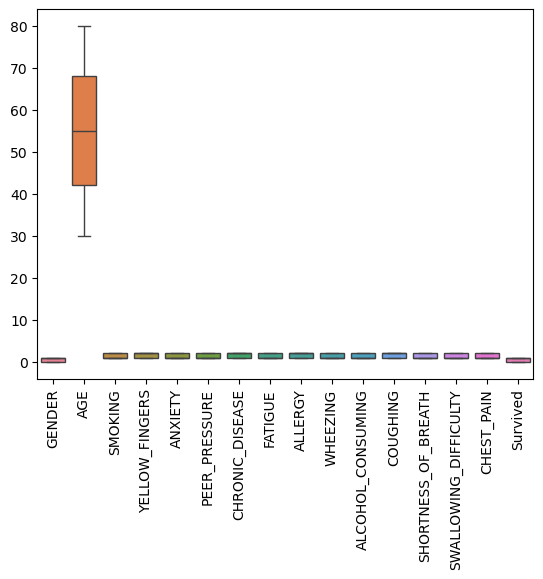

In [44]:
sns.boxplot(data = df1)
plt.xticks(rotation=90)
plt.show()

In [27]:
a = df1.corr()

<Axes: >

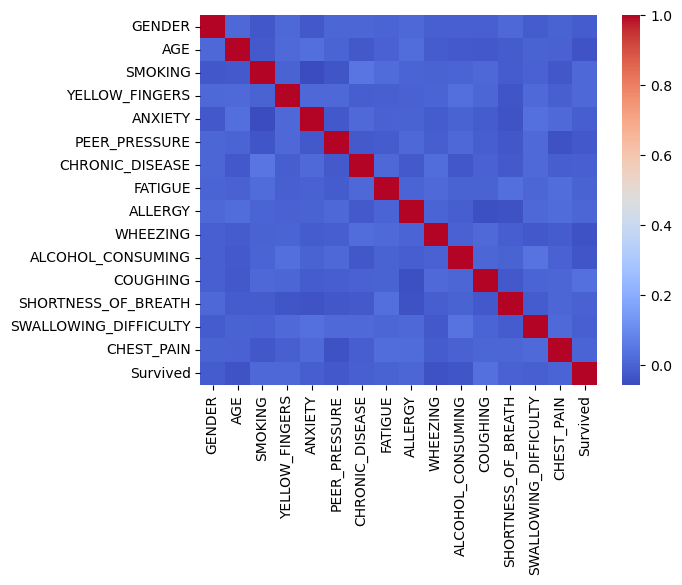

In [28]:
sns.heatmap(a,cmap='coolwarm')

array([[<Axes: title={'center': 'GENDER'}>,
        <Axes: title={'center': 'AGE'}>,
        <Axes: title={'center': 'SMOKING'}>,
        <Axes: title={'center': 'YELLOW_FINGERS'}>],
       [<Axes: title={'center': 'ANXIETY'}>,
        <Axes: title={'center': 'PEER_PRESSURE'}>,
        <Axes: title={'center': 'CHRONIC_DISEASE'}>,
        <Axes: title={'center': 'FATIGUE'}>],
       [<Axes: title={'center': 'ALLERGY'}>,
        <Axes: title={'center': 'WHEEZING'}>,
        <Axes: title={'center': 'ALCOHOL_CONSUMING'}>,
        <Axes: title={'center': 'COUGHING'}>],
       [<Axes: title={'center': 'SHORTNESS_OF_BREATH'}>,
        <Axes: title={'center': 'SWALLOWING_DIFFICULTY'}>,
        <Axes: title={'center': 'CHEST_PAIN'}>,
        <Axes: title={'center': 'Survived'}>]], dtype=object)

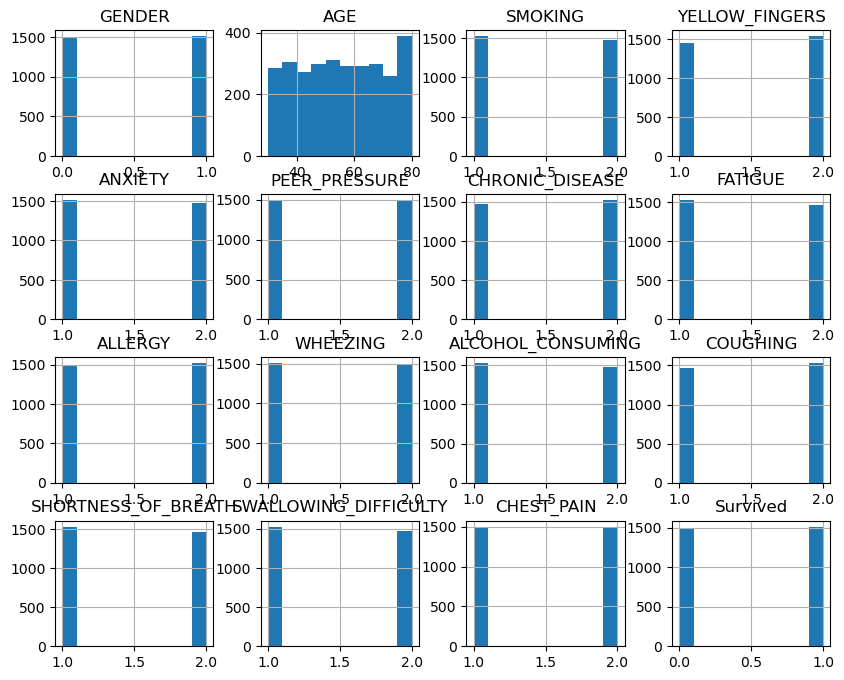

In [29]:
df1.hist(figsize=(10,8))

In [30]:
df1.columns

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC_DISEASE', 'FATIGUE', 'ALLERGY', 'WHEEZING',
       'ALCOHOL_CONSUMING', 'COUGHING', 'SHORTNESS_OF_BREATH',
       'SWALLOWING_DIFFICULTY', 'CHEST_PAIN', 'Survived'],
      dtype='object')

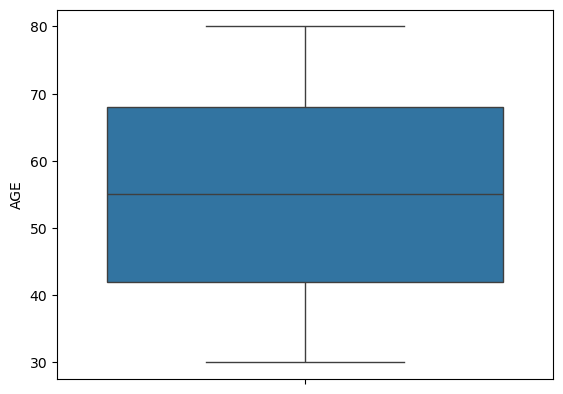

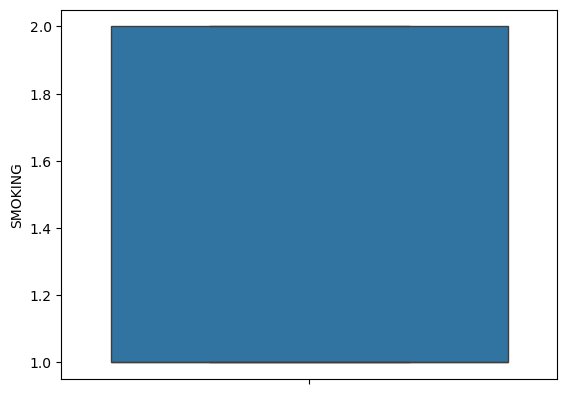

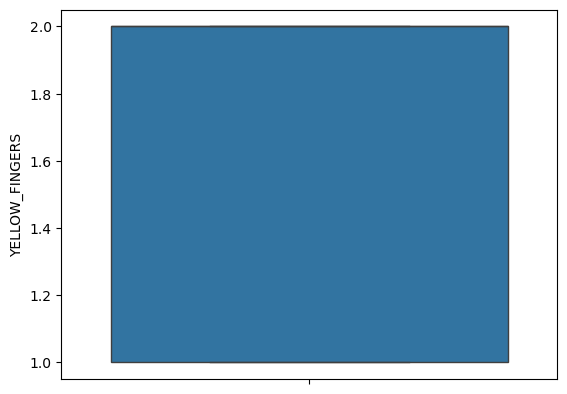

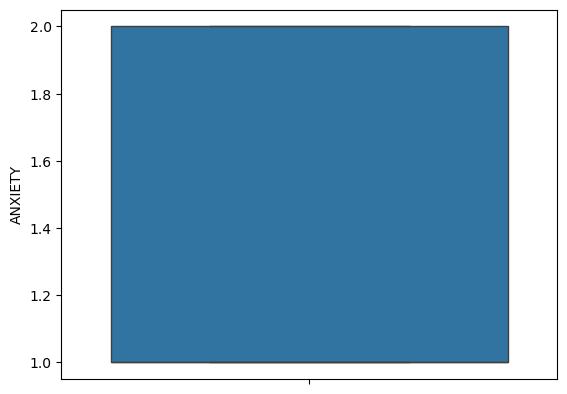

In [31]:
col= ['AGE','SMOKING','YELLOW_FINGERS','ANXIETY']
for c in col:
    sns.boxplot(df1[c])
    plt.show()


In [32]:
from sklearn.feature_selection import SelectKBest,f_classif   

In [33]:
selector = SelectKBest(score_func=f_classif, k=10)
X_new = selector.fit_transform(X, y)
selected_features = X.columns[selector.get_support()]
selected_features

Index(['GENDER', 'AGE', 'SMOKING', 'YELLOW_FINGERS', 'ANXIETY',
       'PEER_PRESSURE', 'CHRONIC_DISEASE', 'WHEEZING', 'ALCOHOL_CONSUMING',
       'COUGHING'],
      dtype='object')

In [34]:
y.value_counts()

Survived
1    1517
0    1481
Name: count, dtype: int64

In [35]:
from sklearn.model_selection import train_test_split

In [36]:
x_train,x_test,y_train, y_test =train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
print('x_train shape:',x_train.shape,'\nx_test shape:',x_test.shape,'\ny_train shape:',y_train.shape,'\ny_test shape:',y_test.shape)

x_train shape: (2398, 15) 
x_test shape: (600, 15) 
y_train shape: (2398,) 
y_test shape: (600,)


In [38]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [39]:
ss=StandardScaler()
x_train_scaled=ss.fit_transform(x_train)
x_test_scaled=ss.transform(x_test)

In [40]:
models = {
    'LogisticRegression': LogisticRegression(),
    'RandomForest': RandomForestClassifier(),
    'GradientBoosting': GradientBoostingClassifier(random_state=42)
}